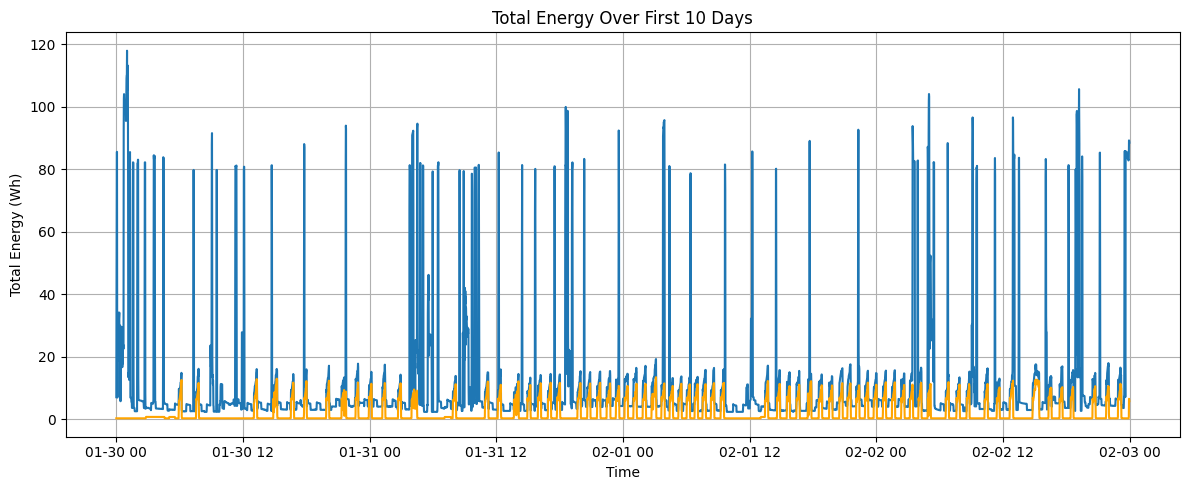

,HVAC_Energy_usage_KWh,total_energy,pump_energy,hvac_energy,Tin,Tout,RH
timestamps,,,,,,,
2022-08-14 13:35:00,0.000090,2.692948,0.0900,0.0903,26.666667,25.67,43.00
2022-08-14 13:36:00,0.000089,2.687115,0.0892,0.0894,26.666667,25.83,43.00
2022-08-14 13:37:00,0.000090,2.679060,0.0894,0.0897,26.666667,25.89,43.00
2022-08-14 13:38:00,0.000089,2.667116,0.0889,0.0892,26.666667,25.94,43.00
2022-08-14 13:39:00,0.000091,2.658783,0.0903,0.0906,26.666667,26.00,43.00
...,...,...,...,...,...,...,...
2022-08-14 15:10:00,0.000089,2.716558,0.0889,0.0894,25.933333,26.00,44.90
2022-08-14 15:11:00,0.000089,2.713780,0.0892,0.0894,25.911111,25.89,44.95
2022-08-14 15:12:00,0.000091,2.702947,0.0903,0.0906,25.888889,25.83,45.00


In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt

folder_path = 'datasets/retrofit'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        df = df[['Timestamp', 'Outdoor_Temp_C', 'Indoor_Temperature_C', 'Indoor_RH_Percent', 'First_Floor_Heat_Pump_KWh', 'Overall_Energy_usage_KWh', 'HVAC_Energy_usage_KWh']]
        df['total_energy'] = df['Overall_Energy_usage_KWh'] * 1000
        df['pump_energy'] = df['First_Floor_Heat_Pump_KWh'] * 1000
        df['hvac_energy'] = df['HVAC_Energy_usage_KWh'] * 1000
        df['Tin'] = df['Indoor_Temperature_C']
        df['Tout'] = df['Outdoor_Temp_C']
        df['RH'] = df['Indoor_RH_Percent']
        df['timestamps'] = pd.to_datetime(df['Timestamp'])
        
        df.drop(columns=['Overall_Energy_usage_KWh', 'First_Floor_Heat_Pump_KWh', 'Timestamp', 'Outdoor_Temp_C', 'Indoor_Temperature_C', 'Indoor_RH_Percent'], inplace=True)
        df.set_index('timestamps', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)

df = dfs[0]
start_date = '2023-01-30'
end_date = '2023-02-02'
df_10days = df.loc[start_date:end_date]
plt.figure(figsize=(12, 5))
plt.plot(df_10days.index, df_10days['total_energy'], label='Total Energy')
plt.plot(df_10days.index, df_10days['hvac_energy'], label='HVAC Usage', color='orange')
plt.title('Total Energy Over First 10 Days')
plt.xlabel('Time')
plt.ylabel('Total Energy (Wh)')
plt.grid(True)
plt.tight_layout()
plt.show()

dfs[0].head(100)

In [34]:
import os

agg_rules = {
    'total_energy': 'sum',
    'hvac_energy': 'sum',
    'pump_energy': 'sum',
    'Tout': 'mean',
    'Tin': 'mean',
    'RH': 'mean',
}
dfs_resampled = []
for index, df in enumerate(dfs):    
    valid_rules = {col: agg_rules[col] for col in df.columns if col in agg_rules}

    df_resampled = df.resample('15T').agg(valid_rules)

    dfs_resampled.append(df_resampled)
    df_resampled.to_csv(os.path.join('datasets/retrofit/resampled', f'resampled_{index}.csv'))


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_14640\788880739.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df.resample('15T').agg(valid_rules)


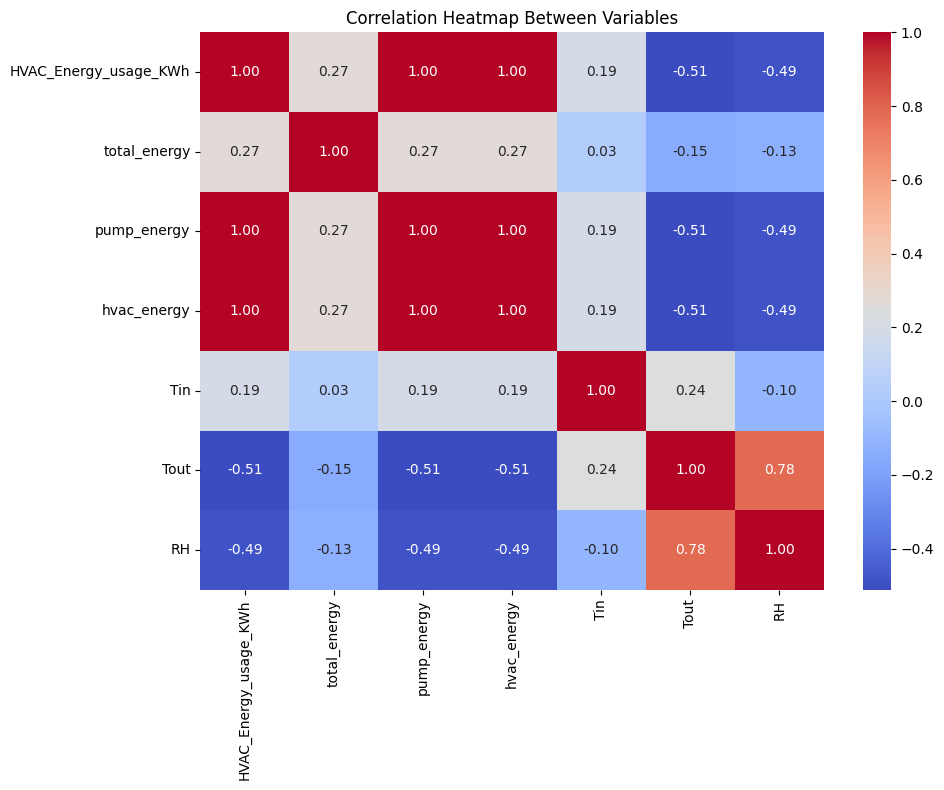

In [23]:
import seaborn as sns
corr = dfs[7].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Between Variables')
plt.tight_layout()
plt.show()

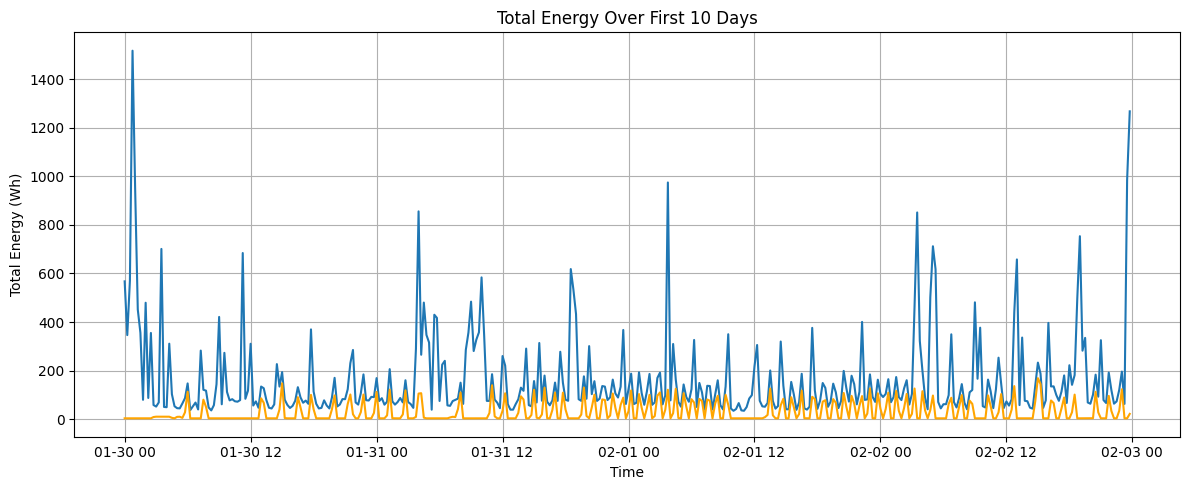

In [18]:
df = dfs_resampled[0]
start_date = '2023-01-30'
end_date = '2023-02-02'
df_10days = df.loc[start_date:end_date]
plt.figure(figsize=(12, 5))
plt.plot(df_10days.index, df_10days['total_energy'], label='Total Energy')
plt.plot(df_10days.index, df_10days['hvac_energy'], label='HVAC Usage', color='orange')
plt.title('Total Energy Over First 10 Days')
plt.xlabel('Time')
plt.ylabel('Total Energy (Wh)')
plt.grid(True)
plt.tight_layout()
plt.show()

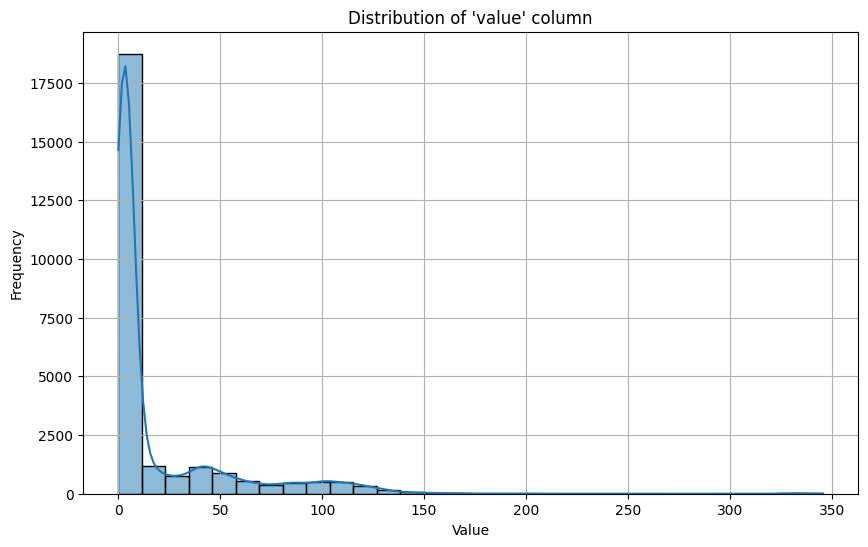

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(dfs_resampled[0]['pump_energy'], bins=30, kde=True)
plt.title("Distribution of 'value' column")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [35]:
agg_rules = {
    'total_energy': 'sum',
    'hvac_energy': 'sum',
    'pump_energy': 'sum',
    'Tout': 'mean',
    'Tin': 'mean',
    'RH': 'mean',
}

folder_path = 'datasets/retrofit'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        df = df[['Timestamp', 'Outdoor_Temp_C', 'Indoor_Temperature_C', 'Indoor_RH_Percent', 'First_Floor_Heat_Pump_KWh', 'Overall_Energy_usage_KWh', 'HVAC_Energy_usage_KWh']]
        df['total_energy'] = df['Overall_Energy_usage_KWh'] * 1000
        df['pump_energy'] = df['First_Floor_Heat_Pump_KWh'] * 1000
        df['hvac_energy'] = df['HVAC_Energy_usage_KWh'] * 1000
        df['Tin'] = df['Indoor_Temperature_C']
        df['Tout'] = df['Outdoor_Temp_C']
        df['RH'] = df['Indoor_RH_Percent']
        df['timestamps'] = pd.to_datetime(df['Timestamp'])
        
        df.drop(columns=['Overall_Energy_usage_KWh', 'First_Floor_Heat_Pump_KWh', 'Timestamp', 'Outdoor_Temp_C', 'Indoor_Temperature_C', 'Indoor_RH_Percent'], inplace=True)
        df.set_index('timestamps', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)
        
dfs_resampled = []
for index, df in enumerate(dfs):    
    print(df.head())
    valid_rules = {col: agg_rules[col] for col in df.columns if col in agg_rules}

    df_resampled = df.resample('15min').agg(valid_rules)

    df_resampled['pump_energy'] = df_resampled['pump_energy'].where(df_resampled['pump_energy'] >= 10, 0)
    df_resampled['hvac_energy'] = df_resampled['hvac_energy'].where(df_resampled['hvac_energy'] >= 10, 0)

    dfs_resampled.append(df_resampled)
    df_resampled.to_csv(os.path.join('datasets/retrofit/resampled', f'resampled_{index}.csv'))

                     HVAC_Energy_usage_KWh  total_energy  pump_energy  \
timestamps                                                              
2022-08-14 13:35:00               0.000090      2.692948       0.0900   
2022-08-14 13:36:00               0.000089      2.687115       0.0892   
2022-08-14 13:37:00               0.000090      2.679060       0.0894   
2022-08-14 13:38:00               0.000089      2.667116       0.0889   
2022-08-14 13:39:00               0.000091      2.658783       0.0903   

                     hvac_energy        Tin   Tout    RH  
timestamps                                                
2022-08-14 13:35:00       0.0903  26.666667  25.67  43.0  
2022-08-14 13:36:00       0.0894  26.666667  25.83  43.0  
2022-08-14 13:37:00       0.0897  26.666667  25.89  43.0  
2022-08-14 13:38:00       0.0892  26.666667  25.94  43.0  
2022-08-14 13:39:00       0.0906  26.666667  26.00  43.0  
                     HVAC_Energy_usage_KWh  total_energy  pump_energy  \
ti

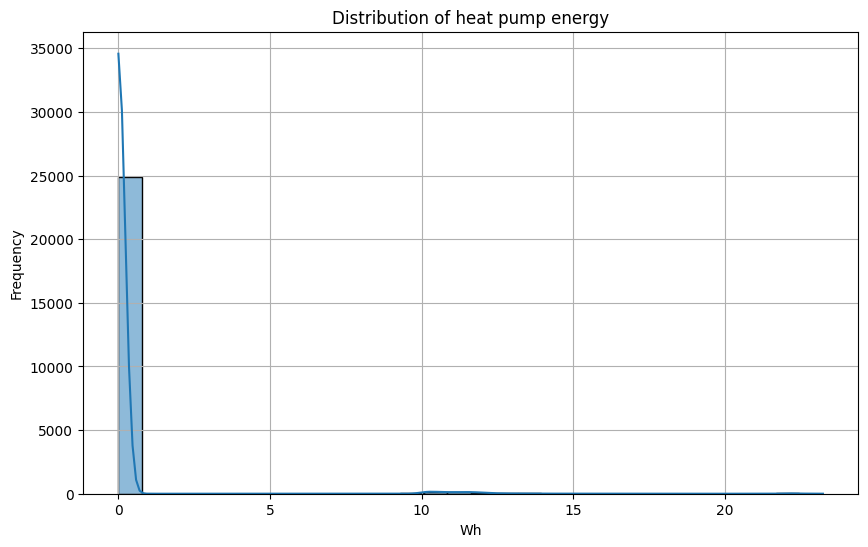

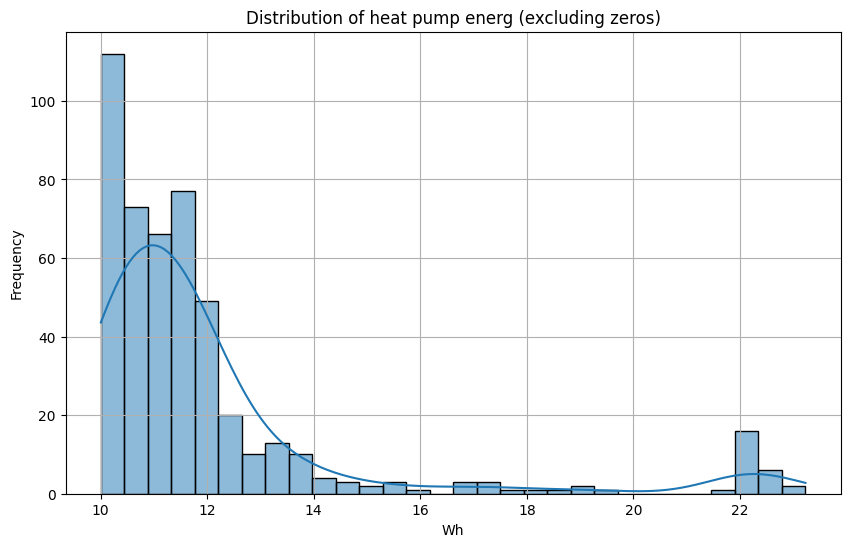

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(dfs_resampled[0]['pump_energy'], bins=30, kde=True)
plt.title("Distribution of heat pump energy")
plt.xlabel("Wh")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(dfs_resampled[0]['pump_energy'][dfs_resampled[0]['pump_energy'] > 0], bins=30, kde=True)
plt.title("Distribution of heat pump energ (excluding zeros)")
plt.xlabel("Wh")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

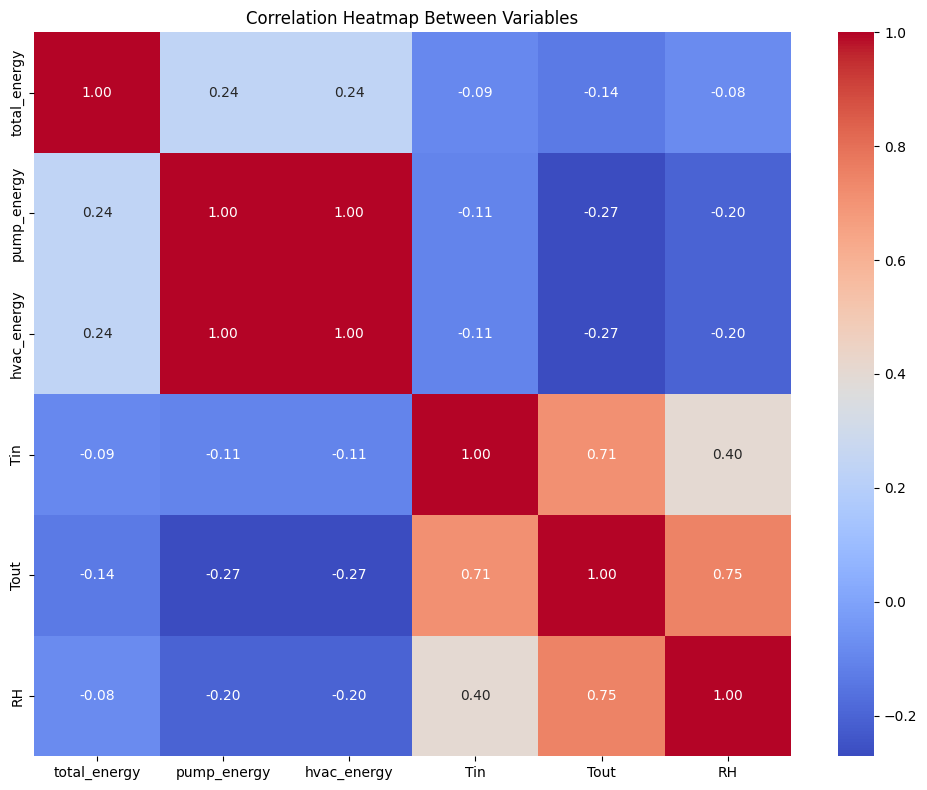

In [36]:
import seaborn as sns
corr = dfs_resampled[0].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Between Variables')
plt.tight_layout()
plt.show()